In [1]:
from collections import Counter
import numpy as np

In [ ]:
class Node:
    def __init__(self, feature =None, value =None,results =None, true_branch= None, false_branch= None):
        self.feature = feature # features to split on 
        self.value = value #value of the feature to split on
        self.results = results #stores class labels if node is a leaf node
        self.true_branch = true_branch #branch for vlaues that are true for the feature. another tree node
        self.false_branch = false_branch #branch for the values that are false for the feature. another tree node
 

Cross entropy H(p,q)
 can be interpreted as the number of bits per message needed (on average) to encode events drawn from true distribution p
, if using an optimal code for distribution q
. Cross entropy takes a minimum value of H(p)
 (the Shannon entropy of p
) when q=p
. The better the match between q
 and p
, the shorter the message length.

[1 2 3 4 5 6 7 8 9]
[0 ,1 ,1 ,0, 1,1,1]
feature is the attribute you can make a desion about, for example age, in this case position. 

In [4]:
def entropy(data):
    counts = np.bincount(data)
    probabilities = counts / len(data)
    entropy = -np.sum([p* np.log2(p) for p in probabilities if p > 0]) 
    return entropy

The split_data function divides a dataset into two subsets based on a specified feature and threshold value. It uses NumPy to identify indices where the feature values satisfy the condition (<= value for the true branch and > value for the false branch). Then, it extracts the corresponding subsets for features (true_X and false_X) and labels (true_y and false_y). The function returns these subsets, enabling the partitioning of data for further use in constructing a decision tree.

In [37]:
def split_data(X, y,feature, value):
    true_indicies =  np.where(X[:,feature] <= value)[0]
    false_indices = np.where(X[:, feature] > value)[0]
    true_X, true_y = X[true_indicies], y[true_indicies]
    false_X, false_y = X[false_indices], y[false_indices]
    return true_X, true_y,false_X, false_y

                            

In [35]:
def build_tree(X, y):
    if len(set(y)) == 1:
        return Node(results=y[0])

    best_gain = 0
    best_criteria = None
    best_sets = None
    n_features = X.shape[1]

    current_entropy = entropy(y)

    for feature in range(n_features):
        feature_values = set(X[:, feature])
        for value in feature_values:
            true_X, true_y, false_X, false_y = split_data(X, y, feature, value)
            true_entropy = entropy(true_y)
            false_entropy = entropy(false_y)
            p = len(true_y) / len(y)
            gain = current_entropy - p * true_entropy - (1 - p) * false_entropy

            if gain > best_gain:
                best_gain = gain
                best_criteria = (feature, value)
                best_sets = (true_X, true_y, false_X, false_y)

    if best_gain > 0:
        true_branch = build_tree(best_sets[0], best_sets[1])
        false_branch = build_tree(best_sets[2], best_sets[3])
        return Node(feature=best_criteria[0], value=best_criteria[1], true_branch=true_branch, false_branch=false_branch)

    return Node(results=y[0])

In [ ]:
def predict(tree, sample):
    if tree.results is not None:
        return tree.results
    else:
        branch = tree.false_branch
        print(branch)
        if sample[tree.feature] <= tree.value:
            branch = tree.true_branch
        return predict(branch, sample)

In [27]:
X[:5]

array([1, 2, 3, 4, 5])

In [40]:
X = np.array([[1,0],[2,0],[3,0],[4,1],[5,1],[6,1],[7,1],[8,0],[9,0],[10,1],[11,1]])
y = np.array([1, 1, 1,1,0, 0,0 ,0,0,1,1])

# Building the tree
decision_tree = build_tree(X, y)

In [77]:
sample = np.array([2,0])
prediction = predict(decision_tree, sample)
print(f"Prediction for sample {sample}: {prediction}")

Prediction for sample [2 0]: 1


In [90]:
decision_tree.false_branch.value

9

In [79]:
decision_tree.results

In [65]:
def print_tree(tree, indent=""):
    """
    Print decision tree in a readable format
    
    Args:
        tree: The decision tree (nested dict structure)
        indent: Current indentation level (for recursion)
    """
    # If it's a leaf node (class label)
    if not isinstance(tree, dict):
        print(f" => {tree}")
        return
    
    # Otherwise it's a decision node
    for attribute, subtree in tree.items():
        if isinstance(subtree, dict):
            # This is a branch with further splits
            for value, branch in subtree.items():
                print(f"{indent}[{attribute} = {value}]", end="")
                if isinstance(branch, dict):
                    print()  # New line before recursing
                    print_tree(branch, indent + "  ")
                else:
                    print(f" => {branch}")
        else:
            # Direct prediction
            print(f"{indent}[{attribute}] => {subtree}")

# Usage:
print_tree(decision_tree)




 => <__main__.Node object at 0x000001D32646A6C0>


In [11]:
# probability P = [1, 0 ,0 ] [ cat , tree , person]

import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(0, 1, 50)

def log_loss (y_true, y_pred):
    """
    Calculate the log loss (cross-entropy loss) for multi-class classification.
    
    Args:
        y_true: True class labels (array-like of shape (n_samples,))
        y_pred: Predicted probabilities (array-like of shape (n_samples, n_classes))"""
    
    loss = - y_true * np.log(y_pred)

    return loss

loss_exampes = [log_loss(1, val) for val in x]

C:\Users\HannahNevill\AppData\Local\Temp\ipykernel_30960\3709727307.py:17: RuntimeWarning: divide by zero encountered in log
  loss = - y_true * np.log(y_pred)


Text(0, 0.5, 'loss example')

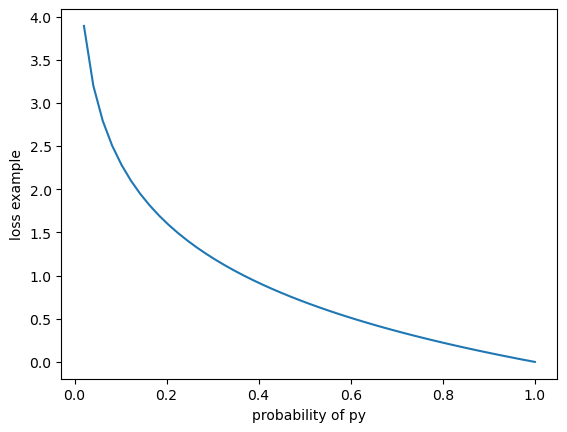

In [12]:
plt.plot(x, loss_exampes)
plt.xlabel('probability of py')
plt.ylabel('loss example')

Note. Can use log base an ything, bsee 2 is bits Log base 2 is used for bits because a bit represents a binary choice between two states (\(0\) or \(1\)), and the logarithm determines the number of those choices required to represent a specific set of information or states. 

#Interesting food for thought. why isn't it one entropy minus the other entropy.

P = [0.5, 0.5]     → H(P) = 1 bit
Q = [0.99, 0.01]   → H(Q) ≈ 0.08 bits

H(P) - H(Q) ≈ 0.92 bits  (just a difference)
H(P, Q) ≈ 6.6 bits       (huge cost! Q is very wrong about P)

Encdiong.
Data:    A  B  A  A  B  A  B  B
Encoded: 0  1  0  0  1  0  1  1
         
Total: 8 bits for 8 symbols = 1 bit/symbol ✓

Sequence: AAAAAAAAAAAAAAABAAAA (20 symbols: 19 A's, 1 B)
Expected bits ≈ 0.08 × 20 = 1.6 bits total!
"15, B, 4" encoded needs:
- 15 → maybe 5-7 bits (depends on max run length)
- B  → 1 bit (binary choice)  
- 4  → 3-5 bits

Total: ~10-13 bits for 20 symbols
     = 0.5-0.65 bits/symbol



Shannon came u p with entropy concept in com puter as a concept to quanity data communication, and quanity data comporession.
In comp uter theory the information represetns the theoretical miniumum amouont of bit used to communicate a distribution. 

For example, if a coin toss goes

HHHHHHHHHH

The entropy of this distribution is 1llog(1) = 0 

so given a prioro coverstaion, aka 'i am about the flip a coin with only heads, here are the resuls......blank' it takes no informatioin to convey the results.

For a distrubtion HHHHHHTTTPPTHTPHTPTH  0.3H, 0.7P 0.1T , the entropy of each term is ____, with means I need this amout of bits on average for each term.

I will encode the rare terms with a longer code (more bits)
and I will encode the short  bit with the 

https://eli.thegreenplace.net/2025/cross-entropy-and-kl-divergence/

"Cross-entropy measures the coding cost when your model is wrong. The extra bits above the minimum (KL divergence) quantifies exactly HOW wrong you are."

KL divergence is  D_KL(P || Q) =  ∑ P(x) * log(P(x) / Q(x))

same as ∑ P(x) * log(P(x) -  logQ(x))

Lets have a look at the entropy of various data sets.  

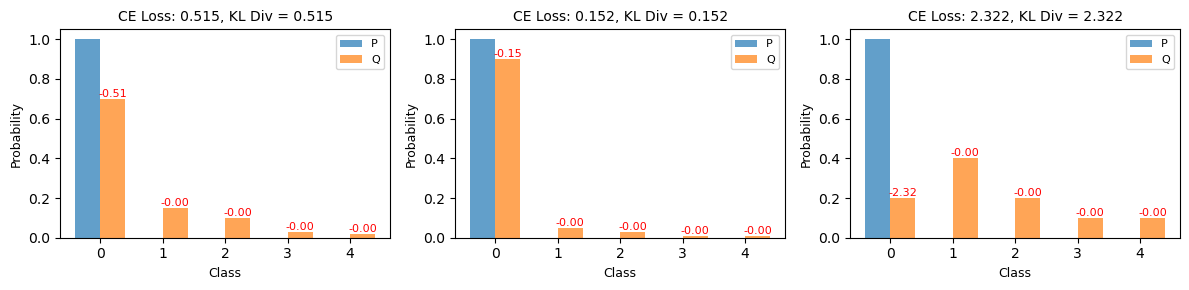

In [ ]:
def cross_entropy_comparison(distributions):
    """
    distributions: list of (P, Q, title) tuples
    """
    # Calculate rows needed for 3 columns
    n = len(distributions)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    # Flatten axes array for easy iteration
    if n > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    
    for ax, (P, Q) in zip(axes, distributions):
        bar_width = 0.4
        loss = -np.sum([p * np.log2(q) for p, q in zip(P, Q)])
        ent = [p * np.log2(q) for p, q in zip(P, Q)]
        
        bars1 = ax.bar(L - 0.4, P, bar_width, align='edge', label='P', alpha=0.7)
        bars2 = ax.bar(L, Q, bar_width, align='edge', label='Q', alpha=0.7)
        kl_div = np.sum([p * np.log2(p/q) for p, q in zip(P, Q) if p > 0])
        ax.bar_label(bars2, labels=[f'{e:.2f}' for e in ent], color='red', fontsize=8)
        
        ax.set_title(f'CE Loss: {loss:.3f}, KL Div = {kl_div:.3f}', fontsize=10)
        ax.set_xlabel('Class', fontsize=9)
        ax.set_ylabel('Probability', fontsize=9)
        ax.legend(fontsize=8)
        ax.set_xticks(L)
    
    plt.tight_layout()
    plt.show()

# Usage:
P = np.array([1.0, 0.0, 0.0, 0.0, 0.0])
Q1 = np.array([0.7, 0.15, 0.1, 0.03, 0.02])
Q2 = np.array([0.9, 0.05, 0.03, 0.01, 0.01])
Q3 = np.array([0.2, 0.4, 0.2, 0.1, 0.1])

cross_entropy_comparison([
    (P, Q1),
    (P, Q2),
    (P, Q3)
])

In [ ]:

P = [ 0.1, 0.2, 0.5, 0.2 , 0.1]
Q = [ 0.1, 0.2, 0.5, 0.2 , 0.1]
Q1 = [0.2, 0.2 ,0.2, 0.2, 0.2]
Q2 = [0.1, 0.1, 0.1, 0.6, 0.1]
Q3 = [0.2,0.2,0.4,0.2, 0.001] # Q = [0.2, 0.2, 0.4, 0.2, 0.000006]  # Requires extreme logit gap
Q4 = [0.2,0.2,0.4,0.2, 0.1]



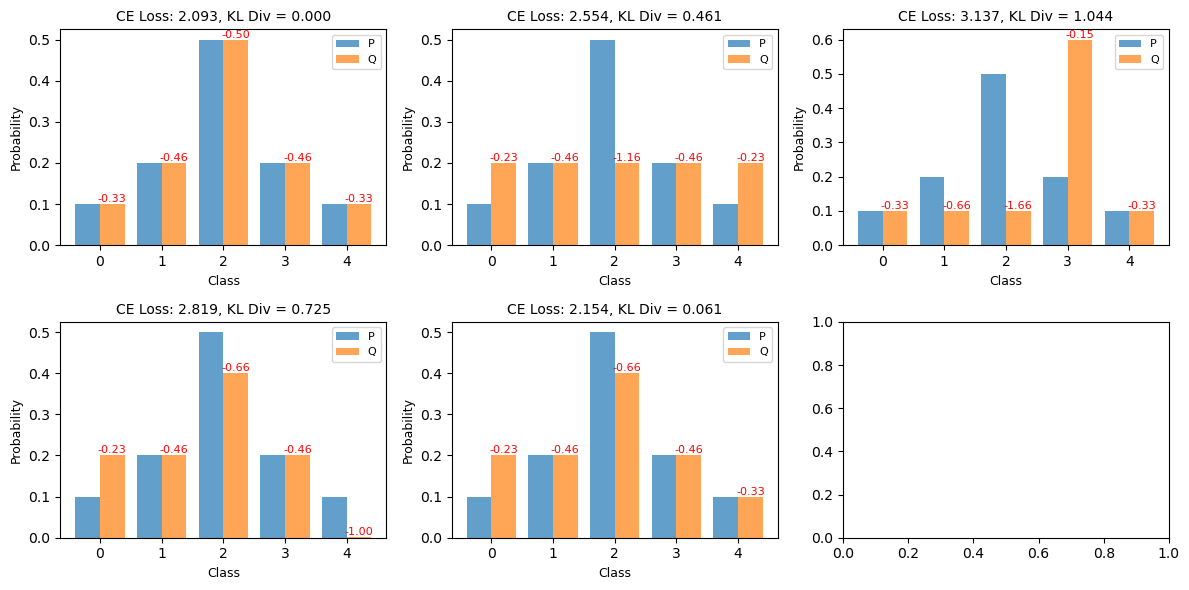

In [ ]:
cross_entropy_comparison([
    (P, Q),
    (P, Q1),
    (P, Q2),
    (P, Q3),
    (P, Q4)])

This is exactly the same as the optimization goal of maximum likelihood estimation. Therefore, we say optimization using log loss in the classification problems is equivalent to do maximum likelihood estimation.

In [79]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Asymptotic bounds:
sigmoid(0)

0.5

Input → Neural Network → Logits (z) → Softmax/Sigmoid → Probabilities (Q) → Cross-Entropy Loss
                          ↑                              ↑
                    raw scores              range (0,1), sum to 1
                    can be anything

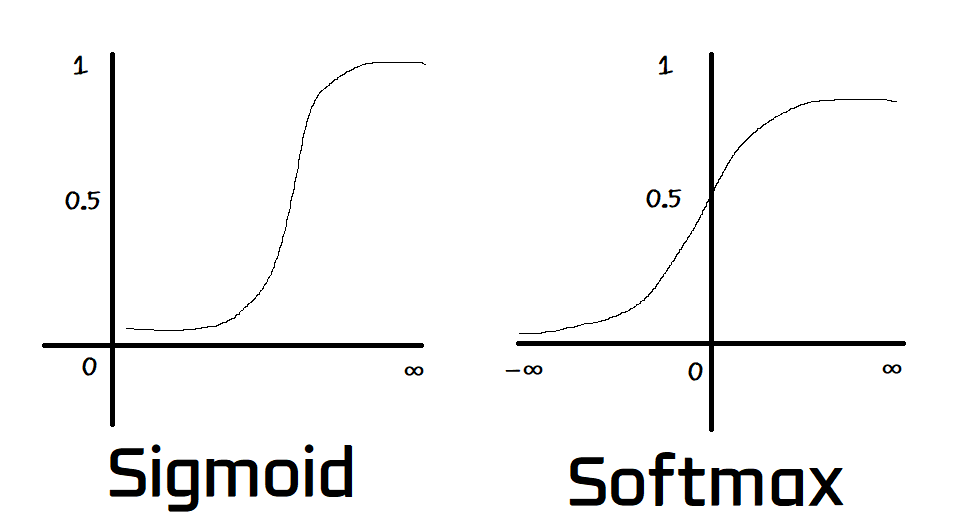